# SVMs with and without Oversampling

In [2]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## 1. Load in Data and Split Training and Testing Data

In [3]:
# Read in the cleaned CSV file
df = pd.read_csv('final_project_data.csv')

# Separate independent and dependent variables
x = df.iloc[:, :-1]
y = df.loc[:, ['conversions']]

# Split the training and testing data with a ratio of 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Convert dependent variable to 1D array to work with sklearn
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

## 2. Create a SVM classifier with linear kernel

In [6]:
# Create SVM classifier with RBF kernel
model = svm.SVC(kernel='linear')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search.fit(x_train, y_train)

# Get best model
best_model = random_search.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred_linear = best_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END .................................C=100, gamma=0.001; total time= 2.2min
[CV] END .................................C=100, gamma=0.001; total time= 2.6min
[CV] END ...............................C=1000, gamma=0.0001; total time= 2.7min
[CV] END .................................C=100, gamma=0.001; total time= 3.0min
[CV] END ...............................C=1000, gamma=0.0001; total time= 3.1min
[CV] END .................................C=100, gamma=0.001; total time= 3.2min
[CV] END ...............................C=1000, gamma=0.0001; total time= 3.2min
[CV] END .................................C=100, gamma=0.001; total time= 3.4min
[CV] END ...................................C=1, gamma=0.001; total time= 1.1min
[CV] END ...................................C=1, gamma=0.001; total time= 1.3min
[CV] END ...................................C=1, gamma=0.001; total time= 1.2min
[CV] END ...................................C=1,

/Users/andreanaargyres/Documents/GitHub/ECS171-Group10/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .................................C=0.1, gamma=0.001; total time= 1.4min
[CV] END .................................C=0.1, gamma=0.001; total time= 1.4min
[CV] END ...............................C=1000, gamma=0.0001; total time= 6.2min
[CV] END .................................C=1000, gamma=0.01; total time= 3.0min
[CV] END .................................C=1000, gamma=0.01; total time= 2.6min
[CV] END .................................C=1000, gamma=0.01; total time= 3.1min
[CV] END ..................................C=100, gamma=0.01; total time= 3.0min
[CV] END ..................................C=100, gamma=0.01; total time= 3.2min
[CV] END ..................................C=100, gamma=0.01; total time= 2.8min
[CV] END .................................C=1000, gamma=0.01; total time= 3.9min
[CV] END ..................................C=100, gamma=0.01; total time= 2.3min
[CV] END ..................................C=100, gamma=0.01; total time= 2.0min
[CV] END ...................

Best Hyperparameters: {'gamma': 0.0001, 'C': 1000}
                   precision    recall  f1-score   support

Not Converted (0)       1.00      0.98      0.99      2063
    Converted (1)       1.00      1.00      1.00     17937

         accuracy                           1.00     20000
        macro avg       1.00      0.99      0.99     20000
     weighted avg       1.00      1.00      1.00     20000

Accuracy: 0.9976


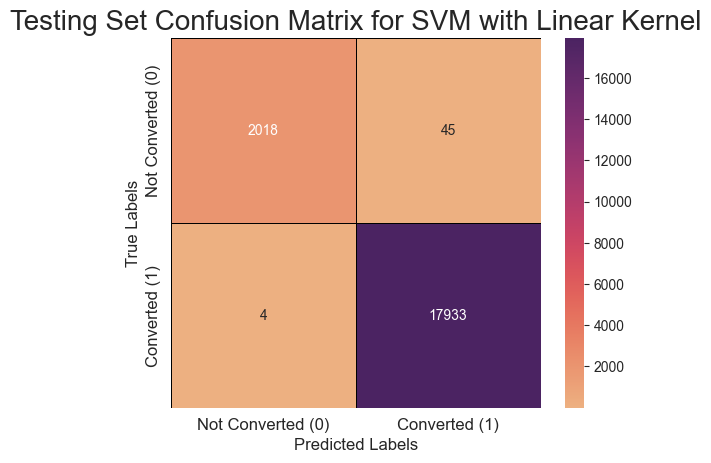

In [7]:
# Save model
joblib.dump(best_model, 'linear_svm.joblib')

# Display best hyperparameters
print(f'Best Hyperparameters: {random_search.best_params_}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred_linear, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred_linear)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

## 3. Create a SVM with RBF kernel

In [6]:
# Create SVM classifier with RBF kernel
rbf_model = svm.SVC(kernel='rbf')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search_rbf.fit(x_train, y_train)

# Get best model
best_rbf_model = random_search_rbf.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred_rbf = best_rbf_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ..................................C=10, gamma=0.001; total time= 1.6min
[CV] END ..................................C=10, gamma=0.001; total time= 1.6min
[CV] END ..................................C=10, gamma=0.001; total time= 1.7min
[CV] END ..................................C=10, gamma=0.001; total time= 1.6min
[CV] END ..................................C=10, gamma=0.001; total time= 1.6min
[CV] END .................................C=1000, gamma=0.01; total time= 4.3min
[CV] END .................................C=1000, gamma=0.01; total time= 4.3min
[CV] END .................................C=1000, gamma=0.01; total time= 4.3min
[CV] END .................................C=100, gamma=0.001; total time= 1.4min
[CV] END .................................C=100, gamma=0.001; total time= 1.4min
[CV] END .................................C=1000, gamma=0.01; total time= 4.6min
[CV] END .................................C=100,

/Users/andreanaargyres/Documents/GitHub/ECS171-Group10/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ..................................C=100, gamma=0.01; total time= 2.4min
[CV] END ..................................C=100, gamma=0.01; total time= 2.5min
[CV] END ..................................C=100, gamma=0.01; total time= 2.6min
[CV] END .....................................C=1, gamma=0.1; total time= 3.7min
[CV] END .....................................C=1, gamma=0.1; total time= 3.9min
[CV] END .....................................C=1, gamma=0.1; total time= 3.4min
[CV] END ..................................C=100, gamma=0.01; total time= 2.3min
[CV] END .....................................C=1, gamma=0.1; total time= 4.1min
[CV] END ..................................C=100, gamma=0.01; total time= 2.4min
[CV] END .................................C=0.1, gamma=0.001; total time= 1.6min
[CV] END .................................C=0.1, gamma=0.001; total time= 1.7min
[CV] END ...................................C=0.1, gamma=0.1; total time= 3.5min
[CV] END ...................

Best Hyperparameters: {'gamma': 0.01, 'C': 1000}
                   precision    recall  f1-score   support

Not Converted (0)       0.94      0.85      0.89      2063
    Converted (1)       0.98      0.99      0.99     17937

         accuracy                           0.98     20000
        macro avg       0.96      0.92      0.94     20000
     weighted avg       0.98      0.98      0.98     20000



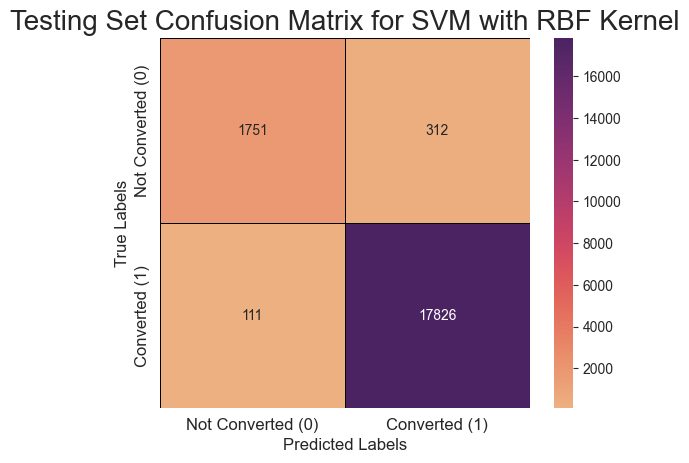

In [11]:
# Save model
joblib.dump(best_rbf_model, 'rbf_svm.joblib')

# Display best hyperparameters
print(f'Best Hyperparameters: {random_search_rbf.best_params_}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

## 4. Oversample the Data
Because `conversions` is imbalanced, with many more 1s than 0s, we use oversampling to address this class imbalance that can bias our models. We apply oversampling only the training data to avoid data leakage.

In [4]:
# Use random oversampling
oversample = RandomOverSampler(random_state=0)

# Apply oversampling to the data
x_over, y_over = oversample.fit_resample(x_train, y_train)

# Summarize the 'conversions' class distribution
distribution = dict(Counter(y_train))
over_distribution = dict(Counter(y_over))
print(f'Class Distribution Before Oversampling:\n1: {distribution[1]}, 0: {distribution[0]}')
print(f'\nClass Distribution After Oversampling:\n1: {over_distribution[1]}, 0: {over_distribution[0]}')


Class Distribution Before Oversampling:
1: 71855, 0: 8145

Class Distribution After Oversampling:
1: 71855, 0: 71855


### 5. Create a SVM classifier with linear kernel
Random search is used to optimize the hyperparameters since it takes significantly less time to run than grid search.

In [5]:
# Create SVM classifier with linear kernel
model = svm.SVC(kernel='linear')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search.fit(x_over, y_over)

# Get best model
best_model = random_search.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred = best_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ..................................C=100, gamma=0.01; total time= 6.3min
[CV] END ..................................C=100, gamma=0.01; total time= 8.7min
[CV] END ..................................C=100, gamma=0.01; total time=12.5min
[CV] END ..................................C=100, gamma=0.01; total time= 8.0min
[CV] END ..................................C=100, gamma=0.01; total time= 7.6min
[CV] END ....................................C=10, gamma=0.1; total time=19.9min
[CV] END ....................................C=10, gamma=0.1; total time=20.8min
[CV] END .................................C=0.1, gamma=0.001; total time= 8.8min


KeyboardInterrupt: 

Best Hyperparameters: {'gamma': 0.01, 'C': 1000}
                   precision    recall  f1-score   support

Not Converted (0)     0.8592    1.0000    0.9243      2063
    Converted (1)     1.0000    0.9812    0.9905     17937

         accuracy                         0.9831     20000
        macro avg     0.9296    0.9906    0.9574     20000
     weighted avg     0.9855    0.9831    0.9837     20000



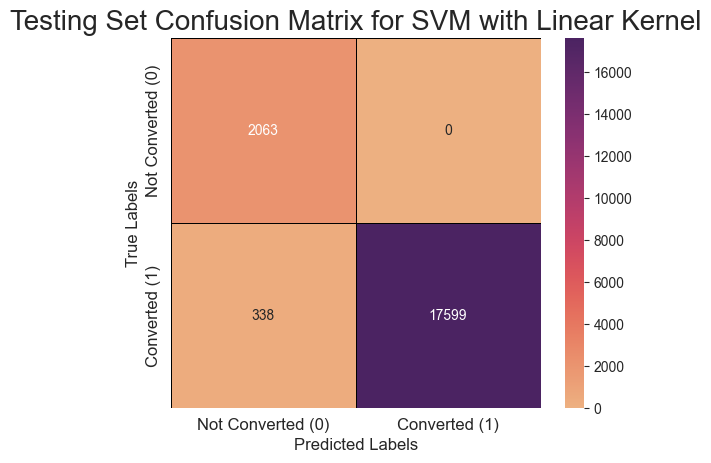

In [11]:
# Save model
joblib.dump(best_model, 'oversampling_linear_svm.joblib')

# Display best hyperparameters
print(f'Best Hyperparameters: {random_search.best_params_}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

### 6. Create a SVM classifier with RBF kernel
Random search is used to optimize the hyperparameters since it takes significantly less time to run than grid search.

In [6]:
# Create SVM classifier with RBF kernel
rbf_model = svm.SVC(kernel='rbf')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search_rbf.fit(x_over, y_over)

# Get best model
best_rbf_model = random_search_rbf.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred_rbf = best_rbf_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ................................C=100, gamma=0.0001; total time= 6.5min
[CV] END ................................C=100, gamma=0.0001; total time= 6.9min
[CV] END ................................C=100, gamma=0.0001; total time= 7.0min
[CV] END ................................C=100, gamma=0.0001; total time= 7.0min
[CV] END ................................C=100, gamma=0.0001; total time= 7.2min
[CV] END .................................C=10, gamma=0.0001; total time= 9.8min
[CV] END .................................C=10, gamma=0.0001; total time=10.3min
[CV] END .................................C=10, gamma=0.0001; total time=10.4min
[CV] END .................................C=10, gamma=0.0001; total time=10.4min


/Users/andreanaargyres/Documents/GitHub/ECS171-Group10/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .................................C=10, gamma=0.0001; total time=10.6min
[CV] END ...................................C=1, gamma=0.001; total time=11.5min
[CV] END ...................................C=1, gamma=0.001; total time=12.4min
[CV] END ...................................C=1, gamma=0.001; total time=12.3min
[CV] END ...................................C=1, gamma=0.001; total time=11.5min
[CV] END ...................................C=1, gamma=0.001; total time=11.5min
[CV] END ...............................C=1000, gamma=0.0001; total time= 4.2min
[CV] END ..................................C=1, gamma=0.0001; total time=15.5min
[CV] END ...............................C=1000, gamma=0.0001; total time= 4.5min
[CV] END ...............................C=1000, gamma=0.0001; total time= 4.5min
[CV] END ...............................C=1000, gamma=0.0001; total time= 4.5min
[CV] END ...............................C=1000, gamma=0.0001; total time= 4.5min
[CV] END ...................

Best Hyperparameters: {'gamma': 1, 'C': 100}
                   precision    recall  f1-score   support

Not Converted (0)     0.1642    0.0528    0.0799      2063
    Converted (1)     0.8989    0.9691    0.9327     17937

         accuracy                         0.8746     20000
        macro avg     0.5316    0.5109    0.5063     20000
     weighted avg     0.8232    0.8746    0.8447     20000



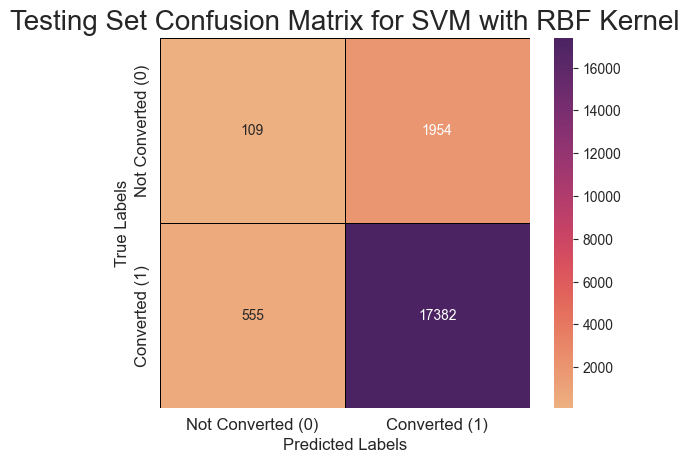

In [7]:
# Save model
joblib.dump(best_rbf_model, 'oversampling_rbf_svm.joblib')

# Display best hyperparameters
print(f'Best Hyperparameters: {random_search_rbf.best_params_}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()